In [4]:
!pip install pandas
!pip install seaborn
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 4.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.3 MB 3.9 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.3 MB 3.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 4.0 MB/s eta 0:00:02
   --------------------- ------------------ 5.0/9.3 MB 4.1 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.3 MB 4.2 MB/s eta 0:00:01
  


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv("D:\\ML projects\\Loan Approval Prediction\\Dataset\\train.csv")
test = pd.read_csv("D:\\ML projects\\Loan Approval Prediction\\Dataset\\test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (58645, 13)
Test Shape: (39098, 12)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [6]:
train.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='str')

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  str    
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  str    
 6   loan_grade                  58645 non-null  str    
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  str    
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), str(4)
memory usa

In [8]:
train.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [9]:
train["loan_status"].value_counts()

loan_status
0    50295
1     8350
Name: count, dtype: int64

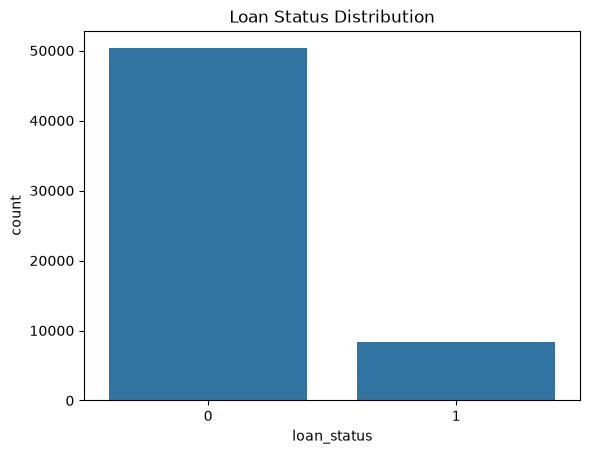

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train, x="loan_status")

plt.title("Loan Status Distribution")
plt.show()

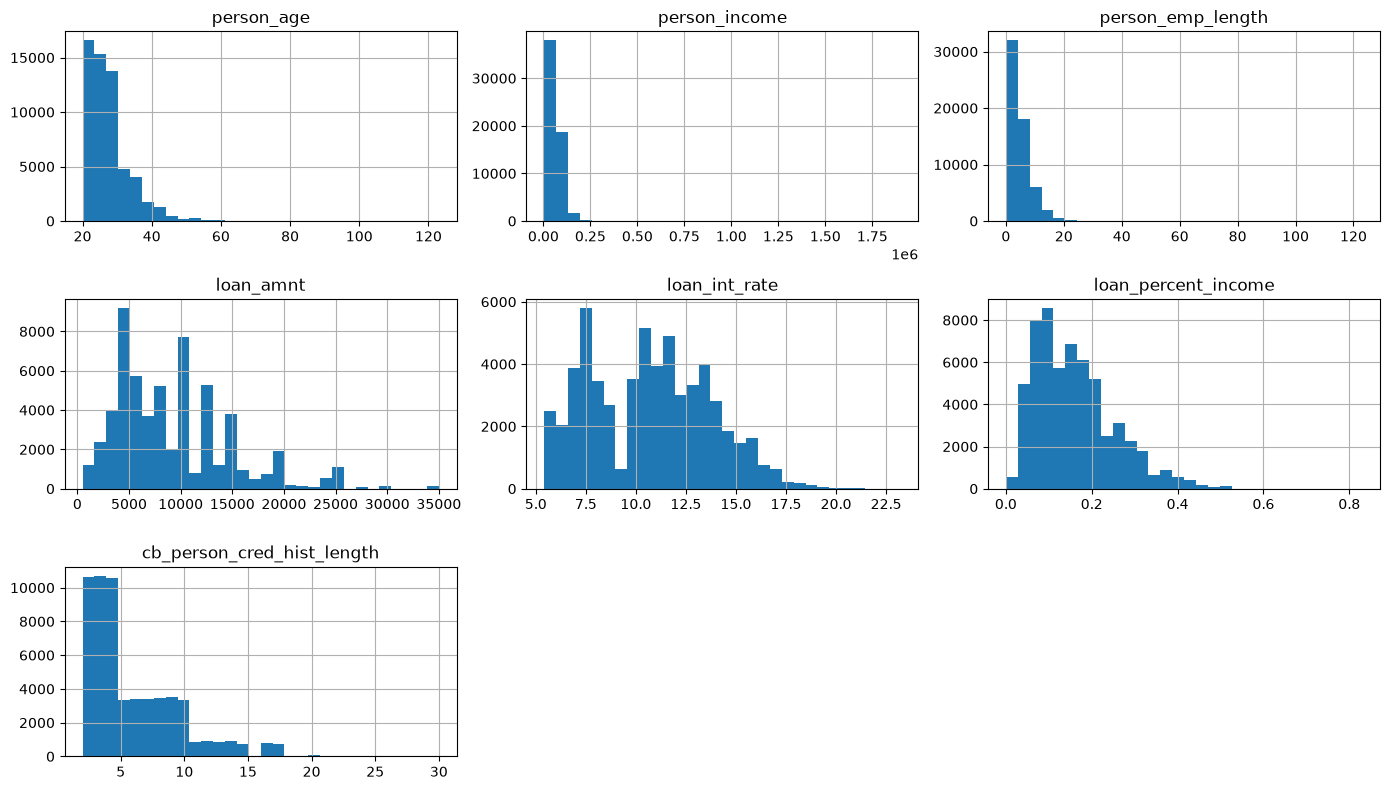

In [11]:
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

train[numeric_cols].hist(
    figsize=(14,8),
    bins=30
)

plt.tight_layout()
plt.show()

In [12]:
categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for col in categorical_cols:
    print("\n", col)
    print(train[col].value_counts())


 person_home_ownership
person_home_ownership
RENT        30594
MORTGAGE    24824
OWN          3138
OTHER          89
Name: count, dtype: int64

 loan_intent
loan_intent
EDUCATION            12271
MEDICAL              10934
PERSONAL             10016
VENTURE              10011
DEBTCONSOLIDATION     9133
HOMEIMPROVEMENT       6280
Name: count, dtype: int64

 loan_grade
loan_grade
A    20984
B    20400
C    11036
D     5034
E     1009
F      149
G       33
Name: count, dtype: int64

 cb_person_default_on_file
cb_person_default_on_file
N    49943
Y     8702
Name: count, dtype: int64


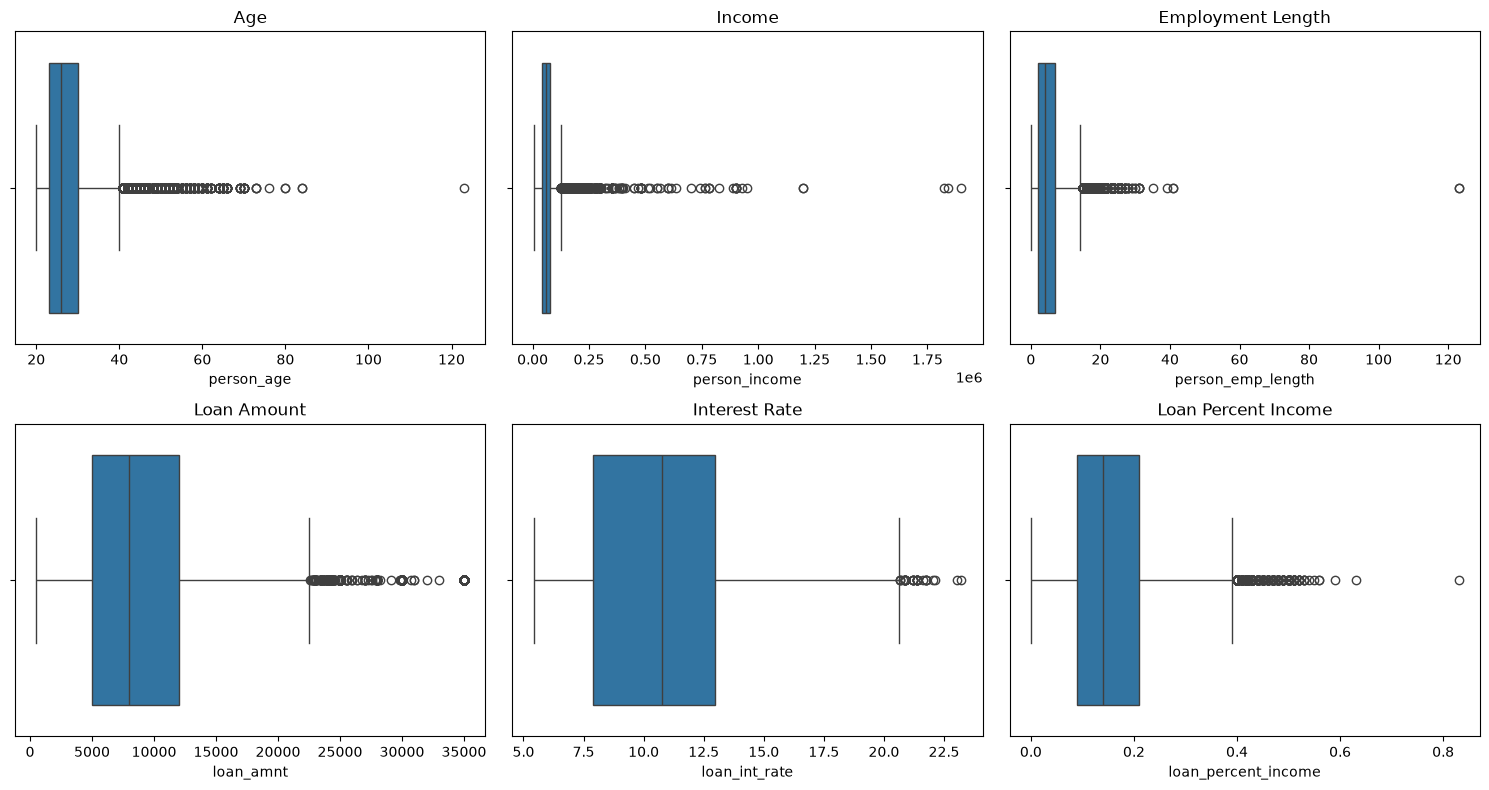

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.boxplot(x=train["person_age"], ax=axes[0,0])
axes[0,0].set_title("Age")

sns.boxplot(x=train["person_income"], ax=axes[0,1])
axes[0,1].set_title("Income")

sns.boxplot(x=train["person_emp_length"], ax=axes[0,2])
axes[0,2].set_title("Employment Length")

sns.boxplot(x=train["loan_amnt"], ax=axes[1,0])
axes[1,0].set_title("Loan Amount")

sns.boxplot(x=train["loan_int_rate"], ax=axes[1,1])
axes[1,1].set_title("Interest Rate")

sns.boxplot(x=train["loan_percent_income"], ax=axes[1,2])
axes[1,2].set_title("Loan Percent Income")

plt.tight_layout()
plt.show()

In [14]:
train["person_age"].sort_values(ascending=False).head(20)


47336    123
4962      84
6750      84
21953     80
15588     80
16954     76
24266     73
25499     73
6425      73
24335     70
27762     70
39143     70
34544     70
53847     70
48382     70
5597      70
38268     70
54765     70
37023     70
9229      69
Name: person_age, dtype: int64

In [15]:
train.loc[
    train["person_age"] == 123,
    "person_age"
] = train["person_age"].median()

test.loc[
    test["person_age"] == 123,
    "person_age"
] = train["person_age"].median()

In [16]:
train.loc[
    train["person_emp_length"] == 123,
    "person_emp_length"
] = train["person_emp_length"].median()

test.loc[
    test["person_emp_length"] == 123,
    "person_emp_length"
] = train["person_emp_length"].median()

In [17]:
train["income_to_loan_ratio"] = train["person_income"] / train["loan_amnt"]  #Gelirin kredi tutarını kaç kez karşıladığı.

train["credit_hist_age_ratio"] = (train["cb_person_cred_hist_length"] / train["person_age"]) #Kredi geçmişinin yaşa oranı.

train["emp_age_ratio"] = (train["person_emp_length"] / train["person_age"]) #Çalışma süresinin yaşa oranı.

test["income_to_loan_ratio"] = test["person_income"] / test["loan_amnt"]

test["credit_hist_age_ratio"] = (test["cb_person_cred_hist_length"] /test["person_age"])

test["emp_age_ratio"] = (test["person_emp_length"] / test["person_age"])

train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,income_to_loan_ratio,credit_hist_age_ratio,emp_age_ratio
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0,5.833333,0.378378,0.000000
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0,14.000000,0.090909,0.272727
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0,4.800000,0.344828,0.275862
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0,5.833333,0.166667,0.466667
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0,10.000000,0.136364,0.090909


In [18]:
x = train.drop(["loan_status", "id"], axis=1)
y = train["loan_status"]

x_test = test.drop("id", axis=1)

In [19]:
x = pd.get_dummies(x, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)


x, x_test = x.align(x_test, join="left", axis=1, fill_value=0)

In [20]:
print("Train Shape:", x.shape)
print("Test Shape:", x_test.shape)

Train Shape: (58645, 25)
Test Shape: (39098, 25)


In [21]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 6.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.2 MB 7.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 8.5 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.6 MB 11.4 MB/s eta 0:00:04
   ---- ----------------------------------- 3.9/36.6 MB 9.5 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/36.6 MB 9.9 MB/s eta 0:00:04
   -------- ------------------------------- 8.1/36.6 MB 10.1 MB/s


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

In [24]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [25]:
y_pred_log = log_model.predict(x_valid_scaled)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_valid, y_pred_log))
print("Precision:", precision_score(y_valid, y_pred_log))
print("Recall:", recall_score(y_valid, y_pred_log))
print("F1 Score:", f1_score(y_valid, y_pred_log))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, y_pred_log))

print("\nClassification Report")
print(classification_report(y_valid, y_pred_log))

Accuracy: 0.9131213232159604
Precision: 0.7793991416309013
Recall: 0.5437125748502994
F1 Score: 0.6405643738977073

Confusion Matrix
[[9802  257]
 [ 762  908]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10059
           1       0.78      0.54      0.64      1670

    accuracy                           0.91     11729
   macro avg       0.85      0.76      0.80     11729
weighted avg       0.91      0.91      0.91     11729



In [28]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 3.8 MB/s eta 0:00:19
    --------------------------------------- 1.6/69.5 MB 4.6 MB/s eta 0:00:15
   - -------------------------------------- 3.1/69.5 MB 5.4 MB/s eta 0:00:13
   -- ------------------------------------- 4.7/69.5 MB 6.1 MB/s eta 0:00:11
   --- ------------------------------------ 6.6/69.5 MB 6.7 MB/s eta 0:00:10
   ----- ---------------------------------- 8.9/69.5 MB 7.6 MB/s eta 0:00:09
   ------ --------------------------------- 10.7/69.5 MB 8.1 MB/s eta 0:00:08
   ------- -------------------------------- 13.1/69.5 MB 8.3 MB/s eta 0:00:07
   -------- ------------------------------- 15.2/69.5 MB 8.4 MB/s eta 0:00:07
   --------- ------------------------------ 17.0/69.5 MB 8.6 MB/s eta 0:00:07
   ----------- ---------------------------- 19.1/69.5 MB 8.7 MB/s eta 0:00:06
   ------------ --------------------------- 21.2/69.5 MB 8.8 MB/s eta 0:00:06



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
y_pred_xgb = xgb_model.predict(x_valid)

In [31]:
print("Accuracy:", accuracy_score(y_valid, y_pred_xgb))
print("Precision:", precision_score(y_valid, y_pred_xgb))
print("Recall:", recall_score(y_valid, y_pred_xgb))
print("F1 Score:", f1_score(y_valid, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_valid, y_pred_xgb))

Accuracy: 0.9515730241282292
Precision: 0.9238461538461539
Recall: 0.7191616766467066
F1 Score: 0.8087542087542088

Confusion Matrix
[[9960   99]
 [ 469 1201]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10059
           1       0.92      0.72      0.81      1670

    accuracy                           0.95     11729
   macro avg       0.94      0.85      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [32]:
final_predictions = xgb_model.predict(x_test)

submission = pd.DataFrame({
    "id": test["id"],
    "loan_status": final_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,loan_status
0,58645,1
1,58646,0
2,58647,1
3,58648,0
4,58649,0


In [33]:
submission.shape

(39098, 2)

In [34]:
import joblib

joblib.dump(xgb_model, "loan_approval_xgb_model.pkl")

['loan_approval_xgb_model.pkl']

In [35]:
import joblib

joblib.dump(list(x.columns), "model_columns.pkl")

['model_columns.pkl']

In [36]:
x_test.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,income_to_loan_ratio,credit_hist_age_ratio,emp_age_ratio,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,23,69000,3.0,25000,15.76,0.36,2,2.760000,0.086957,0.130435,...,False,False,False,False,False,False,False,True,False,False
1,26,96000,6.0,10000,12.68,0.10,4,9.600000,0.153846,0.230769,...,False,True,False,False,True,False,False,False,False,True
2,26,30000,5.0,4000,17.19,0.13,2,7.500000,0.076923,0.192308,...,False,False,True,False,False,False,True,False,False,True
3,33,50000,4.0,7000,8.90,0.14,7,7.142857,0.212121,0.121212,...,False,False,False,False,False,False,False,False,False,False
4,26,102000,8.0,15000,16.32,0.15,4,6.800000,0.153846,0.307692,...,False,False,False,False,False,True,False,False,False,True
